In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
ss2_cell_stats = "/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/TabulaSapien_2025-01-08/cell_stats.csv"
ss2_junc_stats = "/commons/projects/CZI-tabula-sapiens/Leaflet-Analysis/ATSEs/TabulaSapien_2025-01-08/junction_stats.csv"

rh_easysci_cell_stats = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/junctions/EasySciRH_2025-02-26/cell_stats.csv"
rh_easysci_junc_stats = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/EasySci2024/LeafletFA/MetaCells/junctions/EasySciRH_2025-02-26/junction_stats.csv"

In [2]:
# read everything in add column indicating the dataset and concatenate the cell stats and junction stats 
rh_easysci_cell = pd.read_csv(rh_easysci_cell_stats)
rh_easysci_cell["dataset"] = "rh_easysci"
rh_easysci_junc = pd.read_csv(rh_easysci_junc_stats)
rh_easysci_junc["dataset"] = "rh_easysci"

ss2_cell = pd.read_csv(ss2_cell_stats)
ss2_cell["dataset"] = "ss2"
ss2_junc = pd.read_csv(ss2_junc_stats)
ss2_junc["dataset"] = "ss2"

cell_stats = pd.concat([rh_easysci_cell, ss2_cell])
junc_stats = pd.concat([rh_easysci_junc, ss2_junc])


Text(0, 0.5, '# of Junction / Cell')

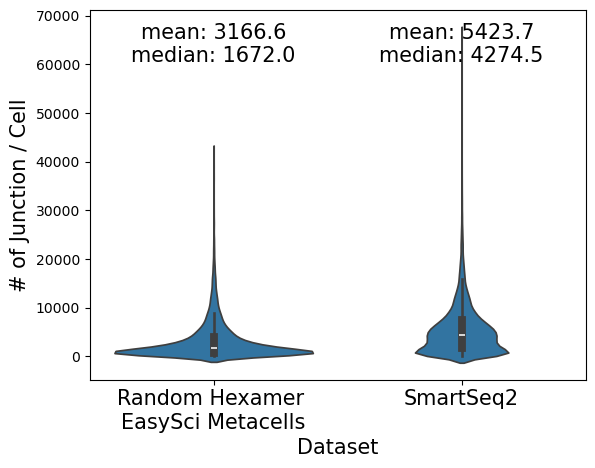

In [5]:
# summarize mean and median junction_count per cell 
cell_stats.groupby("dataset")["junction_count"].agg(["mean", "median"])
# mae a barplot one bar for each dataset y-axis showing violin plot of junction count per cell and median and mean values should be printed on top 
sns.violinplot(data=cell_stats, x="dataset", y="junction_count", fill="dataset")

# add mean and median values to the plot
mean_median = cell_stats.groupby("dataset")["junction_count"].agg(["mean", "median"])

# round the values and plot above the 75% quantile
for i, row in mean_median.iterrows():
    plt.text(i, cell_stats["junction_count"].quantile(0.99999), f"mean: {row['mean']:.1f}\nmedian: {row['median']:.1f}", ha="center", fontsize=15)

# Clean up Xlabels to be "Random Hexamer EasySci" and "SmartSeq2" 
plt.xticks(ticks=[0, 1], labels=["Random Hexamer \nEasySci Metacells", "SmartSeq2"], fontsize=15)
plt.xlabel("Dataset", fontsize=15)
plt.ylabel("# of Junction / Cell", fontsize=15)

In [4]:
junc_stats

,junction_id,total_read_count,cell_count,dataset
0,JH584304.1_55701_56985_-,2122,1466,rh_easysci
1,chr1_25496181_25499823_-,1766,1228,rh_easysci
2,chr1_30860395_30863290_-,153,141,rh_easysci
3,chr1_32506968_32511647_+,200,177,rh_easysci
4,chr1_32698722_32724516_+,106,96,rh_easysci
...,...,...,...,...
5329505,chr8_21909909_21913538_-,3,1,ss2
5329506,chrX_299576_301195_+,18,1,ss2
5329507,chrX_301308_303132_+,6,1,ss2
5329508,chrY_299576_301195_+,18,1,ss2
